In [2]:
import pyvista as pv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import csv
import time
import random
import os 
from scipy.optimize import minimize
from scipy.fftpack import dct
from matplotlib.colors import ListedColormap
from matplotlib.colors import LinearSegmentedColormap


def prod_gaus(mu1, mu2, sigma1, sigma2):
    mu1 = np.array(mu1)
    mu2 = np.array(mu2)
    sigma1 = np.array(sigma1)
    sigma2 = np.array(sigma2)
    
    a = 1 / (2 * sigma1**2)
    b = 1 / (2 * sigma2**2)
    
    # New mean
    muN = (sigma2**2 * mu1 + sigma1**2 * mu2) / (sigma1**2 + sigma2**2)

    # New sigma
    sigmaN = np.sqrt(1 / (2 * (a + b)))

    # Integral
    pre = np.exp(-(a * b / (a + b) * (mu1 - mu2)**2)) / (sigma1 * sigma2 * 2 * np.pi)
    c = pre * np.sqrt(np.pi / (a + b))

    return c, muN, sigmaN, pre


def prod3gauss(mu1, mu2, mu3, sigma1, sigma2, sigma3):
    c, muN, sigmaN, _ = prod_gaus(mu1, mu2, sigma1, sigma2)
    c *= prod_gaus(muN, mu3, sigmaN, sigma3)[0]

    return c, muN, sigmaN


def simulateVV(paras, n, data, biOnly = 1,  strategy = 'ave' , fitType = 'dif'):
    # Import Data into Python
    responses = data[:, [2, 3]]
    stimuli = data[:, [0, 1]]
    N = np.max(stimuli) + 1
    modelprop = []
    dataprop = []
    plt.clf()
    
    # Set Random Seed
    s1 = np.random.get_state()
    s2 = np.random.get_state()
    np.random.seed(13)
    
    # Default Parameters
    sU = 70000.5 
    sD = 70000.5
    sUm = 0
    sDm = 0
    PZ_center = 2
    sigmaZ = 4000
    p_cutoff = 0.5
    
    if len(paras) == 7:
        pcommon = min(abs(paras[0]), 1)
        sigmaU = max(0.1, abs(paras[1]))
        sigmaD = max(0.1, abs(paras[2]))
        sigmaZ = abs(paras[3])
        PZ_center = abs(paras[4])
        sU = abs(paras[5])
        sD = abs(paras[6])
        
    elif len(paras) == 5:
        pcommon = min(abs(paras[0]), 1)
        sigmaU = max(0.1, abs(paras[1]))
        sigmaD = max(0.1, abs(paras[2]))
        sigmaZ = abs(paras[3])
        PZ_center = abs(paras[4])
        
    elif len(paras) == 4:
        pcommon = min(abs(paras[0]), 1)
        sigmaU = max(0.1, abs(paras[1]))
        sigmaD = max(0.1, abs(paras[2]))
        sigmaZ = abs(paras[3])
    
    elif len(paras) == 3:
        pcommon = min(abs(paras[0]), 1)
        sigmaU = max(0.1, abs(paras[1]))
        sigmaD = max(0.1, abs(paras[2]))
        
    elif len(paras) == 2:
        pcommon = 0
        sigmaU = max(0.1, abs(paras[0]))
        sigmaD = max(0.1, abs(paras[1]))
        
    conditions = np.unique(stimuli, axis=0)
    
    # Real Stimuli, Repeat n times
    real = np.tile(conditions, (n, 1))
    
    # Create Mean of Distribution 
    # sU and sD is the 1/rate of increase away from center
    sigma_like = np.zeros((real.shape[0], 2))
    sigma_like[:, 0] = sigmaU * (1 + np.power(np.abs(sUm - real[:, 0]), 1) / sU)
    sigma_like[:, 1] = sigmaD * (1 + np.power(np.abs(sDm - real[:, 1]), 1) / sD)
    
    # Add noise
    noisy = np.zeros_like(real)
    noisy[:, 0] = real[:, 0] + np.random.randn(real.shape[0]) * sigma_like[:, 0]
    noisy[:, 1] = real[:, 1] + np.random.randn(real.shape[0]) * sigma_like[:, 1]
    
    # New sigma_like based on the added noise
    sigma_like[:, 0] = sigmaU * (1 + np.power(np.abs(sUm - np.maximum(0, noisy[:, 0])), 1) / sU)
    sigma_like[:, 1] = sigmaD * (1 + np.power(np.abs(sDm - np.maximum(0, noisy[:, 1])), 1) / sD)

    # Make sure no missing stimuli
    sigma_like[real[:, 0] == 0, 0] = 1000
    sigma_like[real[:, 1] == 0, 1] = 1000
    
    #########
    # Calculate p(C|D,U)
    #########
    
    # CalculetP(U,D|C)
    # Integral of P(U|Z)*P(D|Z)*P(Z)
    PDUC = prod3gauss(noisy[:, 0], noisy[:, 1], PZ_center, sigma_like[:, 0], sigma_like[:, 1], sigmaZ)[0]
    # Integral of P(U|Z)*P(Z) times integral of P(D|Z)*P(Z)
    PDUnC = prod_gaus(noisy[:, 0], PZ_center, sigma_like[:, 0], sigmaZ)[0] * prod_gaus(noisy[:, 1], PZ_center, sigma_like[:, 1],
                                                                                       sigmaZ)[0]

    # Posterior of Common Cause Given Signals
    PCDU = np.multiply(PDUC, pcommon) / (np.multiply(PDUC, pcommon) + np.multiply(PDUnC, 1 - pcommon))
    #print(np.shape(PCDU))
    #########
    # Calculate Sc_hat
    #########
    
    Sc = (
    (sigma_like[:, 1] ** 2 * sigmaZ ** 2 * noisy[:, 0]) +
    (sigma_like[:, 0] ** 2 * sigmaZ ** 2 * noisy[:, 1]) +
    (sigma_like[:, 0] ** 2 * sigma_like[:, 1] ** 2 * PZ_center)
    ) / (
    (sigma_like[:, 0] ** 2 * sigma_like[:, 1] ** 2) +
    (sigma_like[:, 1] ** 2 * sigmaZ ** 2) +
    (sigma_like[:, 0] ** 2 * sigmaZ ** 2)
    )
    
    Snc1 = (
    (sigmaZ ** 2 / (sigma_like[:, 0] ** 2 + sigmaZ ** 2)) * noisy[:, 0] +
    (sigma_like[:, 0] ** 2 / (sigma_like[:, 0] ** 2 + sigmaZ ** 2)) * PZ_center
    )

    Snc2 = (
    (sigmaZ ** 2 / (sigma_like[:, 1] ** 2 + sigmaZ ** 2)) * noisy[:, 1] +
    (sigma_like[:, 1] ** 2 / (sigma_like[:, 1] ** 2 + sigmaZ ** 2)) * PZ_center
    )
    
    # Mean Responses (Sim)
    
    responsesSim = np.zeros((Sc.shape[0], 2))
    if strategy == 'ave' :
        # Averaging 
        responsesSim[:, 0] = PCDU * Sc + (1 - PCDU) * Snc1
        responsesSim[:, 1] = PCDU * Sc + (1 - PCDU) * Snc2
    
    elif strategy == 'sel': 
        # Selecting 
        responsesSim[:, 0] = np.where(PCDU > p_cutoff, Sc, Snc1)
        responsesSim[:, 1] = np.where(PCDU > p_cutoff, Sc, Snc2)
    
    elif strategy == 'mat': 
        # Matching
        p_cutoff = np.random.rand(Sc.shape[0])
        responsesSim[:, 0] = np.where(PCDU > p_cutoff, Sc, Snc1)
        responsesSim[:, 1] = np.where(PCDU > p_cutoff, Sc, Snc2)
      
    
            

    
    # Define Trial Type 
    trialType = 1 + np.dot(stimuli, [N, 1])
    trialTypeSim = 1 + np.dot(real, [N, 1])
    
    #########################################################
    # Create model probabilities/proportions from simulated responses
    modelprop = np.zeros((2, int(np.max(trialType).item()), int(N.item())))
    dataprop = np.zeros((2, int(np.max(trialType).item()), int(N.item())))
    # Numerical list of bimodal conditions
    vector1 = np.ceil(np.arange(1, (N - 1) ** 2 + 1) / (N - 1))
    vector2 = np.tile(np.arange(1, N), int(N.item()) - 1)
    matrix2 = np.vstack((vector1, vector2))
    matrix1 = np.array([N, 1])
    bimodalList = matrix1 @ matrix2
    
    bimodalList = bimodalList.astype(int)
    #print (np.max(trialType))
    '''
    for i in range(2):
        for j in range(1, int(np.max(trialType).item())+1):
            k1 = np.minimum(np.maximum(1, np.round(responsesSim[np.where(trialTypeSim==j),i]).astype(int)),N-1)#need to check
            k1 = k1.ravel().astype(int)
           
            for k in range(len(k1)):
                modelprop[i,j-1,k1[k]] += 1
            print(modelprop)
            k2 = np.minimum(np.maximum(0, np.round(responses[np.where(trialType==j),i]).astype(int)),N-1)
            k2 = k2.ravel().astype(int)
            for k in range(len(k2)):
                 dataprop[i,j-1,k2[k]] += 1
            
            dataprop[i,bimodalList,0] = 0
            dataprop[i,j-1,:] /= (1e-10+np.sum(np.squeeze(dataprop[i,j-1,:])))
            modelprop[i,j-1,:] /= (1e-10+np.sum(np.squeeze(modelprop[i,j-1,:])))
    print(modelprop)
    '''
    for i in range(2):
        for j in range(1, int(np.max(trialType).item())+1):
            k1 = np.minimum(np.maximum(0, np.round(responsesSim[np.where(trialTypeSim==j),i]).astype(int)), N-1)
            k1 = k1.ravel().astype(int)
            counts = np.bincount(k1, minlength=int(N)) 
            modelprop[i, j-1, :] = counts
            
            #print(modelprop)

            k2 = np.minimum(np.maximum(0, np.round(responses[np.where(trialType==j),i]).astype(int)), N-1)
            k2 = k2.ravel().astype(int)
            counts2 = np.bincount(k2, minlength=int(N)) 
            dataprop[i,j-1,:] = np.pad(counts2, (0, 0), mode='constant')

            dataprop[i, bimodalList, 0] = 0
            dataprop[i,j-1,:] /= (1e-10+np.sum(np.squeeze(dataprop[i,j-1,:])))
            modelprop[i,j-1,:] /= (1e-10+np.sum(np.squeeze(modelprop[i,j-1,:])))
     
    '''
    for i in range(2):
            
        trial_types = np.unique(trialType)
        max_trial_type = int(np.max(trialType).item())

        trialTypeMaskSim = trialTypeSim[:, np.newaxis] == trial_types[np.newaxis, :]
        trialTypeMask = trialType[:, np.newaxis] == trial_types[np.newaxis, :]

        k1_counts = np.bincount(np.minimum(np.maximum(1, np.round(responsesSim[np.where(trialTypeMaskSim[:, :, i])]).astype(int)), N-1).ravel(), minlength=4)
        modelprop[i, trial_types-1, :] = k1_counts

        k2_counts = np.bincount(np.minimum(np.maximum(0, np.round(responses[np.where(trialTypeMask[:, :, i])]).astype(int)), N-1).ravel(), minlength=4)
        dataprop[i, trial_types-1, :] = k2_counts


    dataprop[:, bimodalList, 0] = 0
    dataprop /= (1e-10 + np.sum(dataprop, axis=2, keepdims=True))
    modelprop /= (1e-10 + np.sum(modelprop, axis=2, keepdims=True))
    '''
    
    dataprop = dataprop[:, 1:, :]
    modelprop = modelprop[:, 1:, :]

    bimodalList = np.sum(conditions > 0, axis=1) > 1
    unimodal = np.sum(conditions > 0, axis=1) < 2
    
    modelprop[0, conditions[:, 0] == 0, 0] = 1 #recognize no stimulus
    modelprop[0, conditions[:, 0] == 0, 1:] = 0 #never respond 1, 2, 3...N

    modelprop[1, conditions[:, 1] == 0, 0] = 1
    modelprop[1, conditions[:, 1] == 0, 1:] = 0
    
    # Log likelihood
    modelTH = (1-0.001)*modelprop + 0.001*(1/N)
    
    # revert to numbers of responses
    npc = len(stimuli) // (N**2 - 1)  # n responses per condition
    loglike = npc * dataprop * np.log(modelTH)
    
    if biOnly == 1:  # bimodal only
        biORuni = bimodalList
    else:
        biORuni = np.logical_or(unimodal, bimodalList)
        
    model_dat = modelprop[:, biORuni, :]  
    data_dat = dataprop[:, biORuni, :] 
    
    # Multiple ways to define error, to be minimized:
    # Negative sum of log-likelihood
    minus_sll = -np.sum(np.sum(np.sum(loglike[:,biORuni,:])))

    # Negative R2
    x = np.corrcoef(model_dat.ravel(), data_dat.ravel())
    mr2 = -(x[1, 0]**2)

    # Sum Squared Error
    sse = np.sum(np.sum(np.sum((model_dat - data_dat)**2)))

    print("R2 on all")
    print(x[1, 0] ** 2)

    # Calculate sum log likelihood, and the 'best' model if it perfectly matched data
    print("Sum Loglike    Optimal")
    sum_loglike = np.sum(
        npc * dataprop[:, biORuni, :] * np.log((1 - 0.001) * modelprop[:, biORuni, :] + 0.001 / N)
    )
    optimal = np.sum(
        npc * dataprop[:, biORuni, :] * np.log((1 - 0.001) * dataprop[:, biORuni, :] + 0.001 / N)
    )
    print(sum_loglike, optimal)

    # Different way of calculating R2
    A = dataprop[:, biORuni, :]
    B = modelprop[:, biORuni, :]
    avg_data = np.mean(A)
    var_of_data = np.sum((A - avg_data) ** 2)
    avg_diff = np.mean(A - B)
    var_of_diff = np.sum(((A - B - avg_diff) ** 2))
    print("Explainable variance, r2:")
    r_square = 1 - var_of_diff / var_of_data
    print(r_square)
   
    '''
    #Plot
    fig, axs = plt.subplots(2, 2, figsize=(8, 8))

    axs[0, 0].imshow(dataprop[0, :, :])
    axs[0, 0].set_title('Experimental Data, cond V resp')

    axs[0, 1].imshow(dataprop[1, :, :])
    axs[0, 1].set_title('Experimental Data, cond A resp')

    axs[1, 0].imshow(modelprop[0, :, :])
    axs[1, 0].set_title('Model, cond V resp')

    axs[1, 1].imshow(modelprop[1, :, :])
    axs[1, 1].set_title('Model, cond A resp')
    
    plt.savefig("output2.png") 
    plt.figure()
    
    plt.figure()
            
    plt.show()
    '''
    
    #print (loglike)
    
    if fitType == 'mll':
        error = minus_sll
    elif fitType == 'mr2':
        error = mr2
    else:
        error = sse
    
    error += 10000000 * int((sigmaU + sigmaD) < 0)
    
    np.random.set_state(s1)
    
    #np.savetxt('array10.txt', dataprop[1, :, :], fmt='%.6f')
    #np.savetxt('array13.txt', trialType, fmt='%.6f')
    
   
    return error, modelprop, dataprop, responsesSim#, real, sigma_like, noisy, PCDU, Sc

def plotKonrads(data, model=None, save_path=None):
    a = data.shape
    condi = int((a[1] + 1) ** 0.5)
    plt.subplots_adjust(hspace=0.5, wspace=0.5)  

    for i in range(a[1]):
        if condi < 11:
            plt.subplot(condi, condi, i + 2)
        else:
            plt.figure(int(i/condi) + 1)
            plt.subplot(condi, 1, (i % condi) + 1)
        
        plt.plot(data[0, i, :], 'b')
     
        plt.plot(data[1, i, :], 'r')
        plt.axis([0, a[2]-1, 0, 1])

    if model is not None:
        for i in range(a[1]):
            if condi < 11:
                plt.subplot(condi, condi, i+2)
            else:
                plt.figure(int(i/condi) + 1)
                plt.subplot(condi, 1, (i % condi) + 1)
            
           
            plt.plot(model[0, i, :], 'b-.')
            plt.plot(model[1, i, :], 'r-.')
            plt.axis([0, a[2]-1, 0, 1])
    
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    
    plt.show()

def fit(n_parameters, n_Simulation, Behavior_Data, n_seeds = 1, bounds = [(0, 1),(0.1, 3),(0.1, 3),(0.1,3),(0, 3.5)], biOnly = 1, Strategies = ['ave'], FitType = 'mll'):
    result_M = None
    start_time = time.time()
    [13, 1089, 681, 304, 118, 817, 82, 736, 295, 424, 247, 732, 243, 366, 483, 415, 747, 926, 335, 394, 653, 968, 746, 944, 197, 871, 694, 466, 958, 42, 276, 45, 419, 43, 985, 190, 405, 35, 388, 523, 796, 239, 124, 291, 924, 491, 417, 482, 57, 861, 405, 226, 292, 501, 904, 920, 199, 287, 433, 531, 797, 686, 459, 812, 152, 243, 330, 306, 583, 397, 660, 729, 480, 925, 437, 831, 452, 506, 388, 988, 160, 169, 854, 353, 93, 872, 195, 556, 266, 752, 104, 64, 902, 103, 185, 216, 527, 802, 221, 778]
    data = Behavior_Data
    best_error = float('inf')
    best_result = None
    best_strategy = None
    
    for strategy in Strategies:
        for seed in range(n_seeds):
            np.random.seed(random_seeds[seed])
            x0 = np.random.rand(n_parameters)
     
            result = minimize(lambda paras: simulateVV(paras, n_Simulation, data, biOnly, strategy = strategy, fitType=FitType)[0], x0, method='Powell', bounds=bounds)
            if result.success and result.fun < best_error:
                best_error = result.fun
                best_result = result
                best_strategy = strategy
        
    estimated_parameters = best_result.x
    error = best_error
    strategy = best_strategy
    end_time = time.time()     
    execution_time = end_time - start_time  
    print("Running time:", execution_time, "s")

    return estimated_parameters, error, strategy
    


In [3]:
#Fig1
import pyvista as pv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import csv
import time
import random
import os 
from scipy.optimize import minimize
from scipy.fftpack import dct
from matplotlib.colors import ListedColormap
from matplotlib.colors import LinearSegmentedColormap
data = csv_filename = '45_sifi_forMatlab.csv'
data = pd.read_csv(csv_filename, header=None, na_values='NaN')
data=np.array(data)

arr = np.arange(0.1, 2.01, 0.05)


A, B = np.meshgrid(arr, arr)


pairs = np.column_stack((A.ravel(), B.ravel()))

print("pairs", len(pairs))
print("eg.", pairs[:5])
vmat = []

for (a_val, b_val) in pairs:
    paras = [0.5, a_val, b_val, 2, 1.7]
    # simulateVV
    error, modelprop, dataprop, responsesSim = simulateVV(paras, 500, data, biOnly=1, strategy='ave', fitType='mll')
    value = modelprop[0,5,1]
    vmat.append(value)




pairs 1521
eg. [[0.1  0.1 ]
 [0.15 0.1 ]
 [0.2  0.1 ]
 [0.25 0.1 ]
 [0.3  0.1 ]]
R2 on all
0.5532206387514048
Sum Loglike    Optimal
-567.974608991182 -69.90473830103551
Explainable variance, r2:
0.4088985474037664
R2 on all
0.5565916777856081
Sum Loglike    Optimal
-446.1877041243275 -69.90473830103551
Explainable variance, r2:
0.4153549331575994
R2 on all
0.5756132077767238
Sum Loglike    Optimal
-320.8582782016649 -69.90473830103551
Explainable variance, r2:
0.45311004932470234
R2 on all
0.6110623050244409
Sum Loglike    Optimal
-259.1295715190978 -69.90473830103551
Explainable variance, r2:
0.5209572207031813
R2 on all
0.6563188421750058
Sum Loglike    Optimal
-227.3317263711943 -69.90473830103551
Explainable variance, r2:
0.5977110418255058
R2 on all
0.7005359913981187
Sum Loglike    Optimal
-208.7326981873902 -69.90473830103551
Explainable variance, r2:
0.664908484204167
R2 on all
0.7448327553927546
Sum Loglike    Optimal
-187.34802269815611 -69.90473830103551
Explainable varianc

<Figure size 640x480 with 0 Axes>

In [4]:
import numpy as np
import pandas as pd

data = csv_filename = '45_sifi_forMatlab.csv'
data = pd.read_csv(csv_filename, header=None, na_values='NaN')
data = np.array(data)

arr1 = np.arange(0, 1, 0.1) 
arr2 = np.arange(0.1, 2.01, 0.1)
arr3 = np.arange(0.1, 2.01, 0.1)

A, B, C = np.meshgrid(arr1, arr2, arr3, indexing='ij')

# 
triplets = np.column_stack((A.ravel(), B.ravel(), C.ravel()))

# 
# def simulateVV(paras, N, data, biOnly=1, strategy='ave', fitType='mll'):
#     # simulateVV

vmat = []
for (a_val, b_val, c_val) in triplets:
    # 
    paras = [a_val, b_val, c_val, 2, 1.7]
    error, modelprop, dataprop, responsesSim = simulateVV(paras, 500, data, biOnly=1, strategy='ave', fitType='mll')
    result = modelprop[0,5,1]
    vmat.append(result)

# 


R2 on all
0.5532206387514048
Sum Loglike    Optimal
-567.974608991182 -69.90473830103551
Explainable variance, r2:
0.4088985474037664
R2 on all
0.5506875623519564
Sum Loglike    Optimal
-544.3155345259464 -69.90473830103551
Explainable variance, r2:
0.41043825068724415
R2 on all
0.5288697974087936
Sum Loglike    Optimal
-533.8377917230781 -69.90473830103551
Explainable variance, r2:
0.41229112469220974
R2 on all
0.4907069328103811
Sum Loglike    Optimal
-540.8734068453047 -69.90473830103551
Explainable variance, r2:
0.3943208657207188
R2 on all
0.4428922425509187
Sum Loglike    Optimal
-551.5388111309684 -69.90473830103551
Explainable variance, r2:
0.35601858813868636
R2 on all
0.3995096324232486
Sum Loglike    Optimal
-562.3719113116415 -69.90473830103551
Explainable variance, r2:
0.31244703043181676
R2 on all
0.36538955894349545
Sum Loglike    Optimal
-571.1984795150879 -69.90473830103551
Explainable variance, r2:
0.2745260525435249
R2 on all
0.33629022816102966
Sum Loglike    Optima

<Figure size 640x480 with 0 Axes>

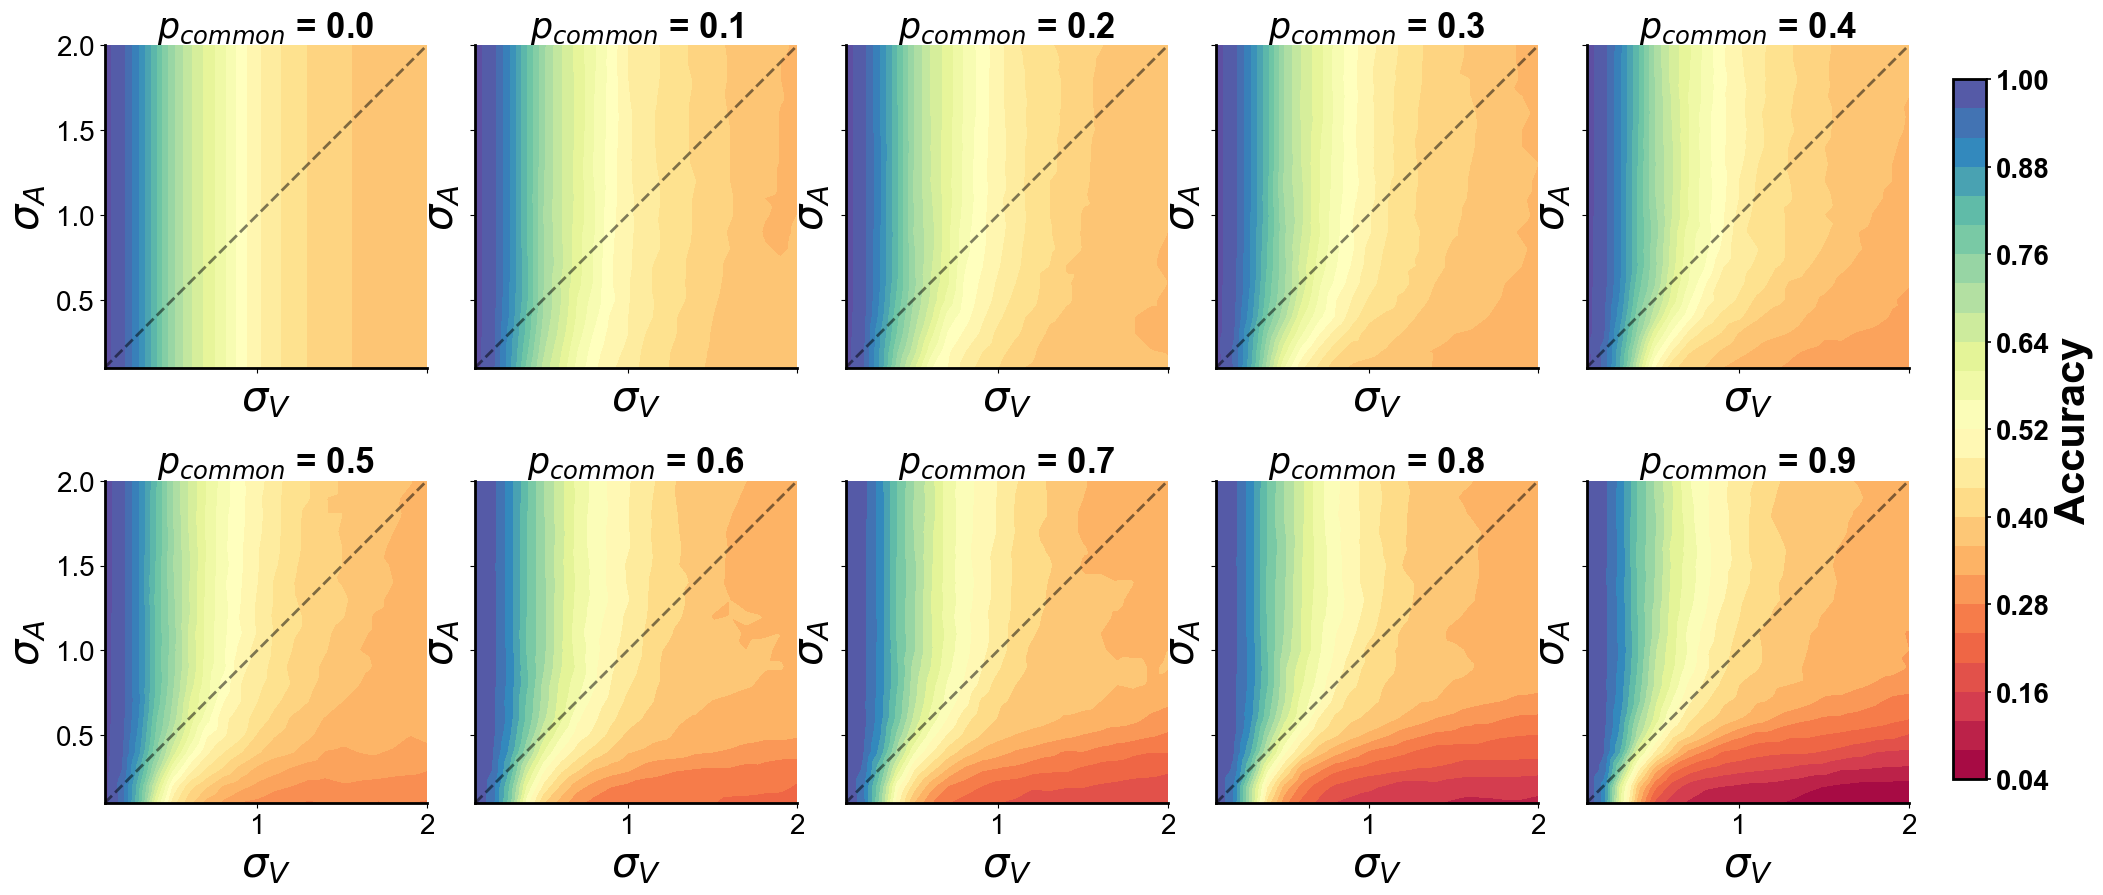

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from matplotlib.colors import Normalize


plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 18,
    'axes.labelsize': 30,
    'axes.titlesize': 20,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 10,
    'figure.titlesize': 50,
    'axes.linewidth': 2,
    'lines.linewidth': 3
})

# ===== triplets = (a, b, c) = (pcommon, σ_V, σ_A)；result = (N,) =====
a = triplets[:, 0]   # pcommon
b = triplets[:, 1]   # σ_V
c = triplets[:, 2]   # σ_A
result = np.asarray(vmat).reshape(-1)

# ===== pcommon 10 （ 2x5 ）=====
a_slices = np.unique(a)            # 
assert len(a_slices) >= 10, "pcommon less than 10,check triplets"
a_slices = a_slices[:10]           # 
# 
diffs = np.diff(np.unique(a))
step = np.median(diffs) if diffs.size > 0 else 0.0
atol = 0.4 * step if step > 0 else 1e-9

# 
vmin, vmax = np.nanmin(result), np.nanmax(result)
norm = Normalize(vmin=vmin, vmax=vmax)

# 
fig, axes = plt.subplots(2, 5, figsize=(22, 10), sharex=True, sharey=True)
axes = axes.ravel()
colormap = 'Spectral'

im = None

for i, a0 in enumerate(a_slices):
    ax = axes[i]

    # 
    mask = np.isclose(a, a0, atol=atol)
    if not np.any(mask):
        ax.set_axis_off()
        ax.set_title(
        r'$p_{common}$ = %.1f' % a0,
        pad=15,
        fontsize=50,
        fontweight='bold'
        )
        continue

    #  σ_V × σ_A 
    b_slice = b[mask]
    c_slice = c[mask]
    r_slice = result[mask]

    # 
    grid_b = np.linspace(b_slice.min(), b_slice.max(), 140)
    grid_c = np.linspace(c_slice.min(), c_slice.max(), 140)
    GB, GC = np.meshgrid(grid_b, grid_c)

    # 
    GR_lin = griddata((b_slice, c_slice), r_slice, (GB, GC), method='linear')
    GR_near = griddata((b_slice, c_slice), r_slice, (GB, GC), method='nearest')
    GR = np.where(np.isnan(GR_lin), GR_near, GR_lin)

    min_val = min(grid_b.min(), grid_c.min())
    max_val = max(grid_b.max(), grid_c.max())

    ax.plot(
        [min_val, max_val],
        [min_val, max_val],
        '--k',
        linewidth=2,
        alpha=0.5
    )

    # 
    im = ax.contourf(GB, GC, GR, levels=24, cmap=colormap, norm=norm)
    ax.set_aspect('equal', adjustable='box')

    # title
    ax.set_title(
    r'$p_{common}$ = %.1f' % a0,
    pad=6,
    fontsize=25,
    fontweight='bold'
    )
    ax.set_xlabel(r'$\sigma_V$', labelpad=6)
    ax.set_ylabel(r'$\sigma_A$', labelpad=6)

    # 美化边框
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# 
for j in range(len(a_slices), len(axes)):
    axes[j].set_axis_off()

# 
fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.90, 0.15, 0.015, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Accuracy', fontsize=30, fontweight='bold')
cbar.ax.tick_params(labelsize=20, width=1.2)
for label in cbar.ax.get_yticklabels():
    label.set_fontweight('bold')



fig.subplots_adjust(
    left=0.06, right=0.88,
    bottom=0.08, top=0.93,
    wspace=0.15, hspace=0.05
)


fig.savefig(
    'fig1result_clean2.svg',
    bbox_inches='tight'
)
plt.show()
